Alexander W. Criswell 9/23/26

Scaffolding for normalizing flow prototyping with zuko, built on a toy single-band version of the
thresholder and a toy population model.

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import legwork as lw
import scipy.stats as scst
from tqdm import tqdm
from corner import corner

import torch
import zuko

## pelargir modules live flat in pelargir/, imported by absolute name
sys.path.insert(0, os.path.abspath(os.path.join('..', 'pelargir')))

from utils import get_amp_freq, lisa_noise_psd, msun_kg_conv, au_m_conv, G, set_style
from thresholding import SNR_Threshold
import flows

set_style()

print('numpy', np.__version__, '| torch', torch.__version__, '| zuko', zuko.__version__)

numpy 2.3.0 | torch 2.11.0+cu130 | zuko 1.6.0


## Toy population model

A minimal stand-in for `PopModel` + `GalacticBinaryPrior`, restricted to one frequency band.

Two population hyperparameters, matching the names used in `inference.PopulationHyperPrior`:

- `m_mu` -- mean of the white dwarf mass distribution, in Msun
- `a_alpha` -- slope of the semi-major axis distribution, p(a) ~ a^a_alpha

Binaries are drawn directly in frequency rather than in `a`, so every draw lands inside the band by
construction. The two are equivalent up to a change of variables: f ~ a^(-3/2), so p(a) ~ a^alpha
induces

    p(f) ~ f^(-(2*alpha + 5)/3)

and `a` is recovered from (m_1, m_2, f) afterwards. The count is Poisson rather than fixed, which
gives genuine realization-to-realization scatter in N_res; note the production model instead fixes
Ntot and lets the resolved count vary only through which binaries happen to be bright enough.

In [3]:
## astrophysical bounds, matching utils.apply_theta_lims('default')
M_MIN, M_MAX = 0.17, 1.44
D_MIN, D_MAX = 1e-3, 100.0
## G, msun_kg_conv and au_m_conv come from utils, so the frequency inversion below
## is guaranteed to invert get_amp_freq exactly. Redefining them here silently
## broke the roundtrip: astropy's Msun is 1.98841e30, not the older 1.98892e30.


class ToyPopulation:
    '''
    Toy single-band galactic binary population.
    '''

    def __init__(self, band, rng, n_expected=20000, m_sigma=0.15, d_scale=4.0):
        '''
        Parameters
        ----------
        band : ToyBand
            The frequency band to populate.
        rng : Generator
            numpy Generator.
        n_expected : int, optional
            Poisson mean of the number of binaries in the band. The default is 20000.
        m_sigma : float, optional
            Width of the mass distribution in Msun. The default is 0.15.
        d_scale : float, optional
            Exponential disk scale length in kpc. The default is 4.

        Returns
        -------
        None.

        '''

        self.band = band
        self.rng = rng
        self.n_expected = int(n_expected)
        self.m_sigma = m_sigma
        self.d_scale = d_scale

        return

    def draw_masses(self, m_mu, size):
        '''Truncated Gaussian white dwarf masses, in Msun.'''

        a, b = (M_MIN - m_mu) / self.m_sigma, (M_MAX - m_mu) / self.m_sigma

        return scst.truncnorm.rvs(a, b, loc=m_mu, scale=self.m_sigma, size=size,
                                  random_state=self.rng)

    def draw_distances(self, size):
        '''Exponential-disk distances, in kpc.'''

        d = self.rng.exponential(self.d_scale, size=size)

        return np.clip(d, D_MIN, D_MAX)

    def draw_frequencies(self, a_alpha, size):
        '''
        GW frequencies inside the band, in Hz.

        Drawn from the power law in f induced by p(a) ~ a^a_alpha, by inverse-CDF sampling.
        '''

        beta = -(2.0 * a_alpha + 5.0) / 3.0
        lo, hi = self.band.f_low, self.band.f_high
        u_draw = self.rng.uniform(size=size)

        if np.isclose(beta, -1.0):
            return lo * (hi / lo) ** u_draw

        p = beta + 1.0

        return (lo ** p + u_draw * (hi ** p - lo ** p)) ** (1.0 / p)

    def sample(self, m_mu, a_alpha, n_binaries=None):
        '''
        Draw one realization of the population.

        Parameters
        ----------
        m_mu : float
            Mean white dwarf mass, in Msun.
        a_alpha : float
            Slope of p(a) ~ a^a_alpha.
        n_binaries : int, optional
            Number of binaries. The default is None (Poisson draw about n_expected).

        Returns
        -------
        theta : array
            Astrophysical parameters of shape (4,N), as [m_1,m_2,d_L,a] in [Msun,Msun,kpc,AU].
        amp : array
            GW strain amplitudes.
        fgw : array
            GW frequencies in Hz.

        '''

        if n_binaries is None:
            n_binaries = self.rng.poisson(self.n_expected)
        n_binaries = int(n_binaries)

        m_1 = self.draw_masses(m_mu, n_binaries)
        m_2 = self.draw_masses(m_mu, n_binaries)
        d_L = self.draw_distances(n_binaries)
        fgw = self.draw_frequencies(a_alpha, n_binaries)

        ## invert f = (1/pi) sqrt(G M / a^3) for the semi-major axis
        m_tot = (m_1 + m_2) * msun_kg_conv
        a = (G * m_tot / (np.pi * fgw) ** 2) ** (1 / 3) / au_m_conv

        theta = np.stack([m_1, m_2, d_L, a], axis=0)
        ## reuse the production amplitude/frequency map rather than duplicating it
        amp, fgw_check = get_amp_freq(theta)

        assert np.allclose(fgw_check, fgw, rtol=1e-8), 'frequency inversion disagrees with get_amp_freq'

        return theta, amp, fgw

## Toy thresholder

A single-band version of `SNR_Threshold.per_frequency_array_sort`. It keeps the two pieces of
physics that matter and drops the coarse-graining machinery:

**Confusion-limited SNR.** Every binary is measured against the instrument noise *plus* the power
of every fainter binary in its bin. With amplitudes sorted ascending,

    rho_i = sqrt( T * A_i^2 / ( S_n + T_eff * (cumsum(A^2) - A_i^2) ) )

**The tilt filter.** `rho >= threshold` can be satisfied non-monotonically, e.g.
`[F, F, T, F, F, T, T]`. Only sources above the *brightest unresolved* binary are genuinely
resolved, so the boolean array is multiplied by its own indices and differenced to locate the last
crossing. The comment in `thresholding.py:136` calls this "a very silly solution, but does work";
it is reproduced exactly here so the toy matches the production split.

The foreground is the summed power of everything left over, converted to a PSD by dividing by the
bin width.

In [4]:
class ToyBand:
    '''
    A single frequency band, subdivided into coarse-grained bins.
    '''

    def __init__(self, f_low=1e-4, f_high=2e-4, n_bins=5, duration=1.262e8):
        '''
        Parameters
        ----------
        f_low, f_high : float, optional
            Band edges in Hz. The defaults are 1e-4 and 2e-4.
        n_bins : int, optional
            Number of coarse-grained bins in the band. The default is 5.
        duration : float, optional
            Mission duration in seconds. The default is 1.262e8 (4 yr).

        Returns
        -------
        None.

        '''

        self.f_low, self.f_high = float(f_low), float(f_high)
        self.n_bins = int(n_bins)
        self.duration = float(duration)

        self.edges = np.linspace(self.f_low, self.f_high, self.n_bins + 1)
        self.fs = 0.5 * (self.edges[:-1] + self.edges[1:])
        self.delta_f = self.edges[1] - self.edges[0]
        ## effective duration set by the coarse-grained resolution, as in SNR_Threshold
        self.duration_eff = 1.0 / self.delta_f

        self.noise_psd = lisa_noise_psd(self.fs, cpu=True)
        self.response = lw.psd.approximate_response_function(self.fs * u.Hz, 19.09 * u.mHz).value

        return

    def bin_index(self, fgw):
        '''Index of the coarse bin each frequency falls in, -1 if outside the band.'''

        idx = np.digitize(fgw, self.edges) - 1

        return np.where((idx >= 0) & (idx < self.n_bins), idx, -1)

    def __repr__(self):
        return 'ToyBand({:.2e}-{:.2e} Hz, {} bins of {:.1e} Hz)'.format(
            self.f_low, self.f_high, self.n_bins, self.delta_f)


class ToyThresholder:
    '''
    Toy single-band resolved/unresolved split.
    '''

    def __init__(self, band):
        '''
        Parameters
        ----------
        band : ToyBand
            The band to threshold within.

        Returns
        -------
        None.

        '''

        self.band = band

        return

    def calc_snr(self, sorted_amps, noise_psd):
        '''
        Confusion-limited SNR, matching SNR_Threshold.calc_Nij().

        Parameters
        ----------
        sorted_amps : array
            Amplitudes sorted ascending along axis 0, of shape (n_max,n_bins).
        noise_psd : array
            Instrument noise PSD per bin, of shape (n_bins,).

        Returns
        -------
        snr : array
            Per-binary SNR, of the same shape as sorted_amps.

        '''

        confusion = self.band.duration_eff * (np.cumsum(sorted_amps ** 2, axis=0) - sorted_amps ** 2)

        return np.sqrt(self.band.duration * sorted_amps ** 2 / (noise_psd + confusion))

    def resolved_filter(self, snr, snr_thresh):
        '''
        Boolean mask of genuinely resolved binaries, via the tilt filter.

        Parameters
        ----------
        snr : array
            Per-binary SNR, ascending in amplitude along axis 0.
        snr_thresh : float
            SNR threshold.

        Returns
        -------
        res_filt : array
            True where a binary is resolved.

        '''

        snr_filt = snr >= snr_thresh

        if snr_filt.shape[0] <= 1:
            return snr_filt

        ## only sources above the brightest *unresolved* binary count as resolved
        tilt = snr_filt * np.arange(snr_filt.shape[0])[:, None]

        return tilt > np.argmax(tilt[1:, ...] - tilt[:-1, ...], axis=0)

    def sort(self, amp, fgw, snr_thresh=7.0):
        '''
        Split a population into resolved and unresolved binaries.

        Parameters
        ----------
        amp : array
            GW strain amplitudes.
        fgw : array
            GW frequencies in Hz.
        snr_thresh : float, optional
            SNR threshold. The default is 7.

        Returns
        -------
        result : dict
            'n_res' per bin, 'n_res_total', 'fg_psd' per bin in Hz^-1, and 'resolved', a boolean
            mask over the input binaries.

        '''

        band = self.band
        bin_idx = band.bin_index(fgw)
        in_band = bin_idx >= 0

        ## pack each bin's amplitudes into a zero-padded column, scaled by the LISA response
        counts = np.bincount(bin_idx[in_band], minlength=band.n_bins)
        n_max = int(counts.max()) if counts.size and counts.max() > 0 else 1
        amp_arr = np.zeros((n_max, band.n_bins))
        source_idx = np.full((n_max, band.n_bins), -1, dtype=int)

        all_idx = np.flatnonzero(in_band)
        for jj in range(band.n_bins):
            sel = all_idx[bin_idx[all_idx] == jj]
            amp_arr[:len(sel), jj] = amp[sel] * np.sqrt(band.response[jj])
            source_idx[:len(sel), jj] = sel

        ## sort ascending, threshold, and read off the split
        order = np.argsort(amp_arr, axis=0)
        sorted_amps = np.take_along_axis(amp_arr, order, axis=0)
        sorted_src = np.take_along_axis(source_idx, order, axis=0)

        snr = self.calc_snr(sorted_amps, band.noise_psd)
        res_filt = self.resolved_filter(snr, snr_thresh)

        n_res = res_filt.sum(axis=0)
        fg_amp = np.sum((sorted_amps * np.invert(res_filt)) ** 2, axis=0)

        resolved = np.zeros(len(amp), dtype=bool)
        hit = sorted_src[res_filt]
        resolved[hit[hit >= 0]] = True

        return {'n_res': n_res, 'n_res_total': int(n_res.sum()),
                'fg_psd': fg_amp / band.delta_f, 'resolved': resolved,
                'sorted_amps': sorted_amps, 'snr': snr, 'res_filt': res_filt}

### Cross-check against the production thresholder

The toy is only useful if its split agrees with `thresholding.py`. `per_frequency_array_sort` is
agnostic about what its trailing axes mean, so the band's bins can be fed in as its realization
axis and the two compared directly on identical inputs.

In [5]:
rng = np.random.default_rng(42)
band = ToyBand(f_low=1e-4, f_high=2e-4, n_bins=5)
pop = ToyPopulation(band, rng, n_expected=20000)
toy_thresher = ToyThresholder(band)

print(band)
print('noise PSD :', np.array2string(band.noise_psd, precision=2))
print('response  :', np.array2string(band.response, precision=3))

theta, amp, fgw = pop.sample(m_mu=0.6, a_alpha=0.5)
toy = toy_thresher.sort(amp, fgw, snr_thresh=7.0)

## the production thresher, built on the same band so delta_f and duration match
real = SNR_Threshold(band.fs, band.noise_psd, band.response, duration=band.duration)
assert np.isclose(real.duration_eff, band.duration_eff), 'effective durations disagree'

## feed the toy's packed amplitude array in with bins on the realization axis
amp_4d = toy['sorted_amps'][:, :, None]
real_nres, real_fg = real.per_frequency_array_sort(amp_4d, band.noise_psd[:, None],
                                                   snr_thresh=7.0)

print()
print('toy  N_res per bin :', toy['n_res'])
print('real N_res per bin :', real_nres.ravel())
print('N_res match        :', np.array_equal(toy['n_res'], real_nres.ravel()))
print('foreground match   :', np.allclose(toy['fg_psd'] * band.delta_f, real_fg.ravel(), rtol=1e-12))

ToyBand(1.00e-04-2.00e-04 Hz, 5 bins of 2.0e-05 Hz)
noise PSD : [3.63e-34 1.37e-34 6.03e-35 2.96e-35 1.58e-35]
response  : [0.3 0.3 0.3 0.3 0.3]

toy  N_res per bin : [ 3 11 10 13  9]
real N_res per bin : [ 3 11 10 13  9]
N_res match        : True
foreground match   : True


## Simulate a toy population

With the split verified, the forward model is: pick hyperparameters and an SNR threshold, draw a
realization, and read off the band observables. Repeated calls at fixed hyperparameters give the
realization scatter.

In [6]:
def run_toy_model(pop, thresher, m_mu, a_alpha, snr_thresh=7.0):
    '''
    One forward model evaluation.

    Parameters
    ----------
    pop : ToyPopulation
        The population to draw from.
    thresher : ToyThresholder
        The thresholder to split with.
    m_mu, a_alpha : float
        Population hyperparameters.
    snr_thresh : float, optional
        SNR threshold. The default is 7.

    Returns
    -------
    result : dict
        'fg_psd' (n_bins,), 'n_res' (n_bins,), 'n_res_total', and 'res_theta' (n_res,4), the
        astrophysical parameters of the resolved binaries in [Msun,Msun,kpc,AU].

    '''

    theta, amp, fgw = pop.sample(m_mu, a_alpha)
    split = thresher.sort(amp, fgw, snr_thresh=snr_thresh)

    return {'fg_psd': split['fg_psd'], 'n_res': split['n_res'],
            'n_res_total': split['n_res_total'], 'res_theta': theta[:, split['resolved']].T}


out = run_toy_model(pop, toy_thresher, m_mu=0.6, a_alpha=0.5)
print('N_res per bin   :', out['n_res'], ' total', out['n_res_total'])
print('foreground PSD  :', np.array2string(out['fg_psd'], precision=2))
print('resolved theta  :', out['res_theta'].shape, '-> [m_1, m_2, d_L, a]')

## realization scatter at fixed hyperparameters
reps = [run_toy_model(pop, toy_thresher, 0.6, 0.5) for _ in range(30)]
n_tot = np.array([r['n_res_total'] for r in reps])
p_tot = np.array([r['fg_psd'].sum() for r in reps])
print()
print('over 30 realizations at fixed Lambda:')
print('  N_res total      %.1f +- %.1f' % (n_tot.mean(), n_tot.std()))
print('  summed fg PSD    %.3e +- %.1e' % (p_tot.mean(), p_tot.std()))
print('  corr(power, N)   %+.3f' % np.corrcoef(p_tot, n_tot)[0, 1])

N_res per bin   : [ 8  6  7  9 12]  total 42
foreground PSD  : [4.25e-35 2.80e-35 1.47e-35 1.11e-35 5.42e-36]
resolved theta  : (42, 4) -> [m_1, m_2, d_L, a]



over 30 realizations at fixed Lambda:
  N_res total      45.4 +- 7.9
  summed fg PSD    9.537e-35 +- 1.5e-35
  corr(power, N)   -0.296


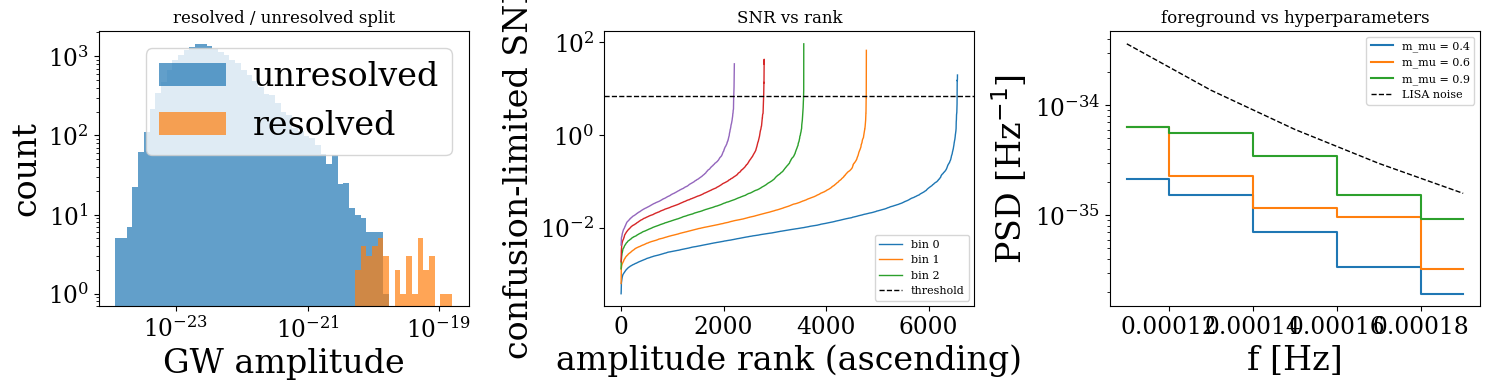

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

## amplitude distribution, split by resolvability
theta, amp, fgw = pop.sample(m_mu=0.6, a_alpha=0.5)
split = toy_thresher.sort(amp, fgw, snr_thresh=7.0)
bins = np.logspace(np.log10(amp.min()), np.log10(amp.max()), 60)
axes[0].hist(amp[~split['resolved']], bins=bins, alpha=0.7, label='unresolved')
axes[0].hist(amp[split['resolved']], bins=bins, alpha=0.7, label='resolved')
axes[0].set(xscale='log', yscale='log', xlabel='GW amplitude', ylabel='count',
            title='resolved / unresolved split')
axes[0].legend()

## SNR against amplitude rank, showing the threshold crossing
snr, res_filt = split['snr'], split['res_filt']
for jj in range(band.n_bins):
    good = split['sorted_amps'][:, jj] > 0
    axes[1].plot(np.arange(good.sum()), snr[good, jj], lw=1,
                 label='bin %d' % jj if jj < 3 else None)
axes[1].axhline(7.0, color='k', ls='--', lw=1, label='threshold')
axes[1].set(yscale='log', xlabel='amplitude rank (ascending)', ylabel='confusion-limited SNR',
            title='SNR vs rank')
axes[1].legend(fontsize=8)

## how the observables respond to the hyperparameters
for m_mu in [0.4, 0.6, 0.9]:
    res = run_toy_model(pop, toy_thresher, m_mu, 0.5)
    axes[2].step(band.fs, res['fg_psd'], where='mid', label='m_mu = %.1f' % m_mu)
axes[2].plot(band.fs, band.noise_psd, 'k--', lw=1, label='LISA noise')
axes[2].set(yscale='log', xlabel='f [Hz]', ylabel='PSD [Hz$^{-1}$]',
            title='foreground vs hyperparameters')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Flow prototyping with zuko

The pattern zuko is built around: a flow is a *lazy* distribution. Calling it with a context
returns a `torch.distributions.Distribution`, which then exposes `log_prob` and `sample`.

Two things bite in this problem and are worth getting right even in a prototype:

- **float64 throughout.** The foreground PSD runs to ~1e-42, which is subnormal in float32 and
  underflows to zero.
- **Work in log space and standardize.** A spline places its knots over a bounded interval, so
  feeding it raw PSD values wastes all the resolution in one knot.

Below is the smallest end-to-end version: build a training set from the toy model, whiten, fit a
conditional NSF over `[log10 fg_psd, N_res]`, and sample from it.

In [8]:
torch.manual_seed(0)
DTYPE = torch.float64

## build a small training set over the hyperparameters and the SNR threshold
n_draws = 600
context_rows, target_rows = [], []

for _ in tqdm(range(n_draws), desc='toy training set'):
    m_mu = rng.uniform(0.3, 1.0)
    a_alpha = rng.uniform(-0.5, 1.5)
    snr_thresh = rng.uniform(5.0, 10.0)
    res = run_toy_model(pop, toy_thresher, m_mu, a_alpha, snr_thresh=snr_thresh)
    context_rows.append([m_mu, a_alpha, snr_thresh])
    ## model the summed band power and the total count: a compact 2-D target
    target_rows.append([res['fg_psd'].sum(), res['n_res_total']])

context = torch.as_tensor(np.array(context_rows), dtype=DTYPE)
target_raw = torch.as_tensor(np.array(target_rows), dtype=DTYPE)

## log10(x + offset); the offset of 1 on the count keeps N_res = 0 finite
OFFSET = torch.as_tensor([0.0, 1.0], dtype=DTYPE)

c_mu, c_sd = context.mean(0), context.std(0)
_log = torch.log10(target_raw + OFFSET)
t_mu, t_sd = _log.mean(0), _log.std(0)
c_w = (context - c_mu) / c_sd


def to_flow_space(raw, dequantize=False):
    '''
    Map physical (power, count) onto whitened log coordinates.

    N_res is discrete, so it is dequantized by adding U(0,1) *before* the log --
    adding noise afterwards, in whitened log space, is a multiplicative smear that
    grows with N and biases the recovered counts high.
    '''

    y = raw.clone()
    if dequantize:
        y[:, 1] = y[:, 1] + torch.rand(len(y), dtype=DTYPE)

    return (torch.log10(y + OFFSET) - t_mu) / t_sd


def from_flow_space(u):
    '''Invert to_flow_space. The floor undoes the dequantization.'''

    y = torch.pow(10.0, u * t_sd + t_mu) - OFFSET
    y[:, 1] = torch.clamp(torch.floor(y[:, 1]), min=0.0)

    return y


t_w = to_flow_space(target_raw)
print('context', tuple(c_w.shape), '-> [m_mu, a_alpha, snr_thresh]')
print('target ', tuple(t_w.shape), '-> [log10 summed fg PSD, log10(N_res + 1)]')

toy training set:   0%|          | 0/600 [00:00<?, ?it/s]

toy training set:   2%|▏         | 13/600 [00:00<00:04, 120.44it/s]

toy training set:   4%|▍         | 26/600 [00:00<00:04, 121.47it/s]

toy training set:   6%|▋         | 39/600 [00:00<00:04, 123.75it/s]

toy training set:   9%|▊         | 52/600 [00:00<00:04, 122.22it/s]

...

toy training set:  93%|█████████▎| 558/600 [00:04<00:00, 112.79it/s]

toy training set:  95%|█████████▌| 571/600 [00:04<00:00, 116.76it/s]

toy training set:  98%|█████████▊| 587/600 [00:04<00:00, 127.53it/s]

toy training set: 100%|██████████| 600/600 [00:04<00:00, 123.51it/s]

context (600, 3) -> [m_mu, a_alpha, snr_thresh]
target  (600, 2) -> [log10 summed fg PSD, log10(N_res + 1)]


training:   0%|          | 0/600 [00:00<?, ?it/s]

training:   0%|          | 1/600 [00:00<02:00,  4.97it/s]

training:   0%|          | 3/600 [00:00<00:59, 10.04it/s]

training:   1%|          | 5/600 [00:00<00:48, 12.36it/s]

training:   1%|          | 7/600 [00:00<00:46, 12.86it/s]

...

training:  99%|█████████▉| 595/600 [00:44<00:00, 13.52it/s]

training: 100%|█████████▉| 597/600 [00:45<00:00, 12.54it/s]

training: 100%|█████████▉| 599/600 [00:45<00:00, 13.19it/s]

training: 100%|██████████| 600/600 [00:45<00:00, 13.25it/s]

loss 1.863 -> -2.372


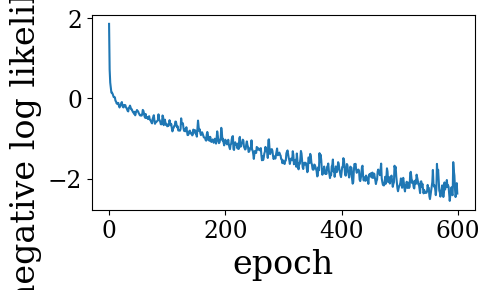

In [9]:
flow = zuko.flows.NSF(features=2, context=3, transforms=3, hidden_features=(64, 64)).to(DTYPE)
optimizer = torch.optim.Adam(flow.parameters(), lr=3e-3)

losses = []
for epoch in tqdm(range(600), desc='training'):
    order = torch.randperm(len(t_w))
    epoch_loss = 0.0
    for start in range(0, len(t_w), 64):
        idx = order[start:start + 64]
        ## redraw the count dequantization every epoch
        u_batch = to_flow_space(target_raw[idx], dequantize=True)
        loss = -flow(c_w[idx]).log_prob(u_batch).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / max(len(range(0, len(t_w), 64)), 1))

print('loss %.3f -> %.3f' % (losses[0], losses[-1]))
plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel('epoch'); plt.ylabel('negative log likelihood'); plt.tight_layout(); plt.show()

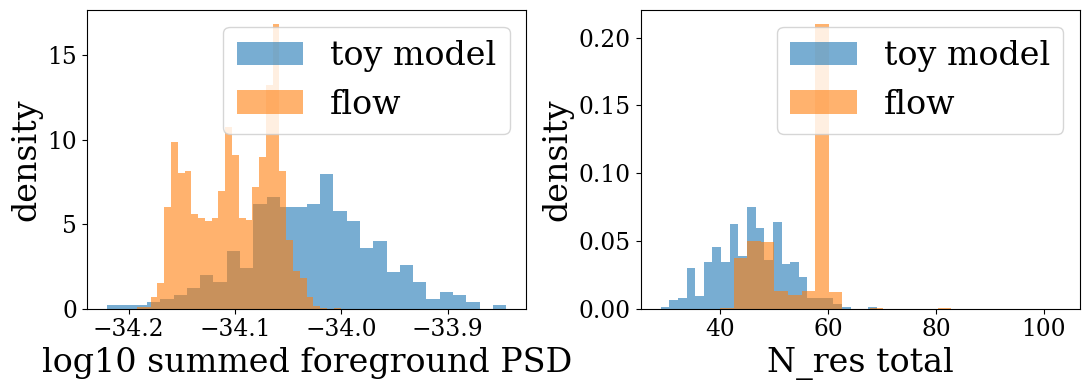

toy  : log10 power -34.029 +- 0.061   N_res 45.7 +- 6.5
flow : log10 power -34.101 +- 0.037   N_res 54.5 +- 6.1


In [10]:
## compare the flow's conditional against the toy model's actual scatter at one context
probe = np.array([0.6, 0.5, 7.0])
probe_w = (torch.as_tensor(probe, dtype=DTYPE) - c_mu) / c_sd

with torch.no_grad():
    drawn = flow(probe_w.expand(4000, -1)).sample()
drawn_phys = from_flow_space(drawn).numpy()

truth = np.array([[r['fg_psd'].sum(), r['n_res_total']]
                  for r in (run_toy_model(pop, toy_thresher, *probe[:2], snr_thresh=probe[2])
                            for _ in range(400))])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log10(truth[:, 0]), bins=30, density=True, alpha=0.6, label='toy model')
axes[0].hist(np.log10(drawn_phys[:, 0]), bins=30, density=True, alpha=0.6, label='flow')
axes[0].set(xlabel='log10 summed foreground PSD', ylabel='density')
axes[0].legend()

axes[1].hist(truth[:, 1], bins=25, density=True, alpha=0.6, label='toy model')
axes[1].hist(drawn_phys[:, 1], bins=25, density=True, alpha=0.6, label='flow')
axes[1].set(xlabel='N_res total', ylabel='density')
axes[1].legend()
plt.tight_layout(); plt.show()

print('toy  : log10 power %.3f +- %.3f   N_res %.1f +- %.1f' % (
    np.log10(truth[:, 0]).mean(), np.log10(truth[:, 0]).std(), truth[:, 1].mean(), truth[:, 1].std()))
print('flow : log10 power %.3f +- %.3f   N_res %.1f +- %.1f' % (
    np.log10(drawn_phys[:, 0]).mean(), np.log10(drawn_phys[:, 0]).std(),
    drawn_phys[:, 1].mean(), drawn_phys[:, 1].std()))

## Where this connects to `flows.py`

The cell above is the bare pattern, with the whitening written out by hand. `flows.py` packages the
same ideas for the real forward model:

- `ElementwiseTransform` -- the log10/logit/affine reparameterization, but with the Jacobian
  tracked, so `log_prob` is a density in physical units rather than in whitened coordinates. That
  matters as soon as the flow is used as a prior.
- `BandFlow` -- one joint NSF over `[S_gw, N_res]` per band, plus a separate flow over the resolved
  binary parameters. The joint is deliberate: `S_gw` and `N_res` are anti-correlated at fixed
  hyperparameters, which the toy above reproduces (see the `corr(power, N)` printout).
- `draw_training_set` / `draw_diagnostic_set` -- the same loop as `run_toy_model`, against a real
  `PopModel`.

Known rough edges are recorded in `BandFlow.joint_log_prob`'s docstring: the count dimension is
marginalized by quadrature that is not converged at the default node count, and the exact fix is a
CDF difference. The toy here sidesteps that entirely by treating `N_res` as continuous after
dequantization.